In [1]:
# ============================================================
# MAPAS DE ANOMALIAS
# ============================================================
# Projeto: Monitoramento de Vegetação — Validação PRA
# Autora: Bruna Bertini
# Data: 2026
#
# Objetivo: Identificar anomalias nas 69 datas de 2020-2025,
#          comparando cada data com o padrão sazonal histórico.
#
# Metodologia:
#   anomalia = valor_data - média_sazonal_do_mesmo_mes
#   Classificação em 5 níveis por z-score
#
# IMPORTANTE: Não chamamos de anomalia climática ou histórica.
#             É anomalia estatística em relação ao padrão
#             sazonal observado (2020-2025).
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"
RESULTS_DIR.mkdir(exist_ok=True)

CORES = {"NDVI": "#2ca02c", "EVI": "#1f77b4", "NDMI": "#ff7f0e"}

print(f"✓ Ambiente configurado")

✓ Ambiente configurado


In [2]:
# ============================================================
# CARREGAR SÉRIES COM ALINHAMENTO AUTOMÁTICO
# ============================================================
# Solução: realinhar todos os rasters à grade de referência
# (definida pelo primeiro arquivo de cada índice)
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import re
from pathlib import Path

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"


def carregar_serie_alinhada(indice):
    """
    Carrega todas as datas intra-anuais de um índice,
    realinhando à grade do primeiro arquivo (referência).
    """
    
    pasta = IND_DIR / indice
    arquivos = sorted(f for f in pasta.glob(f"{indice}_*.tif")
                     if "mediana" not in f.name)
    
    # Usar o PRIMEIRO arquivo como grade de referência
    grade_ref = rioxarray.open_rasterio(arquivos[0]).squeeze()
    
    print(f"\n   Grade de referência ({arquivos[0].name}): {grade_ref.shape}")
    
    resultados = []
    rasters = []
    datas = []
    realinhados = 0
    erros = 0
    
    for arq in arquivos:
        match = re.search(r'(\d{8})', arq.stem)
        if not match:
            continue
        
        data_str = match.group(1)
        data = pd.to_datetime(data_str, format="%Y%m%d")
        
        r = rioxarray.open_rasterio(arq).squeeze()
        
        # Realinhar se shapes diferentes
        if r.shape != grade_ref.shape:
            try:
                r = r.rio.reproject_match(grade_ref)
                realinhados += 1
            except Exception as e:
                print(f"   ⚠️ Erro ao realinhar {arq.name}: {e}")
                erros += 1
                continue
        
        vals = r.values
        rasters.append(vals)
        datas.append(data)
        
        vals_validos = vals[~np.isnan(vals)]
        
        resultados.append({
            "data": data,
            "data_str": data_str,
            "ano": data.year,
            "mes": data.month,
            "media": vals_validos.mean(),
            "mediana": np.median(vals_validos),
            "std": vals_validos.std(),
            "n_pixels": len(vals_validos)
        })
    
    df = pd.DataFrame(resultados).sort_values("data").reset_index(drop=True)
    cubo = np.stack(rasters, axis=0)
    
    print(f"   ✓ {len(df)} datas carregadas")
    print(f"   ✓ {realinhados} realinhadas, {erros} com erro")
    print(f"   ✓ Cubo: {cubo.shape}")
    
    return df, cubo, datas


# ============================================================
# Carregar com alinhamento
# ============================================================
print("=" * 80)
print("CARREGANDO SÉRIES INTRA-ANUAIS (COM ALINHAMENTO)")
print("=" * 80)

series = {}
cubos = {}
datas_ref = None

for indice in ["ndvi", "evi", "ndmi"]:
    print(f"\n📁 Processando {indice.upper()}...")
    df, cubo, datas = carregar_serie_alinhada(indice)
    series[indice.upper()] = df
    cubos[indice.upper()] = cubo
    
    if datas_ref is None:
        datas_ref = datas
    
    print(f"   Período: {df['data'].min().strftime('%Y-%m-%d')} a {df['data'].max().strftime('%Y-%m-%d')}")

# Bounds
ndvi_ref = rioxarray.open_rasterio(IND_DIR / "ndvi" / "ndvi_mediana_2025.tif").squeeze()
left, bottom, right, top = ndvi_ref.rio.bounds()
print(f"\nBounds: {left:.0f}, {bottom:.0f}, {right:.0f}, {top:.0f}")

CARREGANDO SÉRIES INTRA-ANUAIS (COM ALINHAMENTO)

📁 Processando NDVI...

   Grade de referência (ndvi_20200115.tif): (222, 140)
   ✓ 69 datas carregadas
   ✓ 18 realinhadas, 0 com erro
   ✓ Cubo: (69, 222, 140)
   Período: 2020-01-15 a 2025-12-04

📁 Processando EVI...

   Grade de referência (evi_20200115.tif): (222, 140)
   ✓ 69 datas carregadas
   ✓ 0 realinhadas, 0 com erro
   ✓ Cubo: (69, 222, 140)
   Período: 2020-01-15 a 2025-12-04

📁 Processando NDMI...

   Grade de referência (ndmi_20200115.tif): (112, 71)
   ✓ 69 datas carregadas
   ✓ 18 realinhadas, 0 com erro
   ✓ Cubo: (69, 112, 71)
   Período: 2020-01-15 a 2025-12-04

Bounds: 852790, 7398810, 854190, 7401030


In [3]:
# ============================================================
# PADRÃO SAZONAL HISTÓRICO (2020-2025)
# ============================================================
# Média de cada mês usando as 69 datas (todos os anos)
# ============================================================

sazonais = {}

print("=" * 90)
print("PADRÃO SAZONAL HISTÓRICO (2020-2025)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = series[indice]
    
    # Média por mês (usando todas as datas)
    sazonal = df.groupby("mes").agg(
        media=("media", "mean"),
        std=("media", "std"),
        n=("media", "count")
    ).reset_index()
    
    sazonais[indice] = sazonal
    
    print(f"\n📊 {indice}")
    print(sazonal.to_string(index=False, float_format="%.3f"))

# Salvar
for indice, sazonal in sazonais.items():
    output = RESULTS_DIR / f"sazonalidade_{indice.lower()}_historica.csv"
    sazonal.to_csv(output, index=False)

print(f"\n✅ Padrões sazonais salvos em {RESULTS_DIR}")

PADRÃO SAZONAL HISTÓRICO (2020-2025)

📊 NDVI
 mes  media   std  n
   1  0.414 0.080  5
   2  0.486 0.057  5
   3  0.390 0.083  6
   4  0.338 0.063  6
   5  0.332 0.027  6
   6  0.385 0.050  6
   7  0.397 0.034  6
   8  0.344 0.040  6
   9  0.283 0.039  6
  10  0.286 0.043  6
  11  0.312 0.026  6
  12  0.393 0.090  5

📊 EVI
 mes  media   std  n
   1  0.302 0.066  5
   2  0.403 0.112  5
   3  0.329 0.101  6
   4  0.209 0.049  6
   5  0.208 0.047  6
   6  0.281 0.074  6
   7  0.254 0.081  6
   8  0.272 0.071  6
   9  0.196 0.054  6
  10  0.188 0.037  6
  11  0.224 0.050  6
  12  0.354 0.207  5

📊 NDMI
 mes  media   std  n
   1  0.108 0.073  5
   2  0.174 0.053  5
   3  0.072 0.092  6
   4  0.031 0.073  6
   5  0.007 0.030  6
   6  0.053 0.053  6
   7  0.075 0.036  6
   8  0.022 0.047  6
   9 -0.028 0.028  6
  10 -0.035 0.038  6
  11 -0.006 0.015  6
  12  0.084 0.085  5

✅ Padrões sazonais salvos em C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results


In [4]:
# ============================================================
# 8.1 — ANOMALIA POR DATA
# ============================================================
# anomalia = valor_data - média_sazonal_do_mesmo_mes
# Classificação em 5 níveis por z-score
# ============================================================

def classificar_anomalia(z):
    """Classifica anomalia pelo z-score."""
    if z > 1.5:
        return "Muito acima"
    elif z > 0.5:
        return "Acima"
    elif z < -1.5:
        return "Muito abaixo"
    elif z < -0.5:
        return "Abaixo"
    else:
        return "Normal"


dfs_anomalias = {}

print("=" * 90)
print("8.1 — ANOMALIA POR DATA (2020-2025)")
print("=" * 90)

for indice in ["NDVI", "EVI", "NDMI"]:
    df = series[indice].copy()
    sazonal = sazonais[indice]
    
    # Mapear média e std sazonal por mês
    df = df.merge(
        sazonal.rename(columns={"media": "media_sazonal", "std": "std_sazonal"}),
        on="mes",
        how="left"
    )
    
    # Calcular anomalia
    df["anomalia"] = df["media"] - df["media_sazonal"]
    
    # Z-score (evitando divisão por zero)
    df["z_score"] = np.where(
        df["std_sazonal"] > 0.001,
        df["anomalia"] / df["std_sazonal"],
        np.nan
    )
    
    # Classificação
    df["classificacao"] = df["z_score"].apply(classificar_anomalia)
    
    dfs_anomalias[indice] = df
    
    # Resumo
    print(f"\n📊 {indice}")
    print(f"   Média das anomalias: {df['anomalia'].mean():+.3f}")
    print(f"   Std das anomalias:   {df['anomalia'].std():.3f}")
    print(f"\n   Distribuição das classes:")
    for classe in ["Muito acima", "Acima", "Normal", "Abaixo", "Muito abaixo"]:
        n = (df["classificacao"] == classe).sum()
        pct = n / len(df) * 100
        print(f"      {classe:<15} {n:>3} datas ({pct:.1f}%)")
    
    # Top 5 anomalias positivas e negativas
    print(f"\n   Top 5 anomalias POSITIVAS:")
    top_pos = df.nlargest(5, "anomalia")[["data_str", "media", "media_sazonal", "anomalia", "classificacao"]]
    print(top_pos.to_string(index=False, float_format="%.3f"))
    
    print(f"\n   Top 5 anomalias NEGATIVAS:")
    top_neg = df.nsmallest(5, "anomalia")[["data_str", "media", "media_sazonal", "anomalia", "classificacao"]]
    print(top_neg.to_string(index=False, float_format="%.3f"))

# Salvar
df_anomalias_concat = pd.concat(
    dfs_anomalias.values(),
    keys=dfs_anomalias.keys(),
    names=["indice"]
)
output = RESULTS_DIR / "anomalias_por_data.csv"
df_anomalias_concat.to_csv(output)
print(f"\n✅ Salvo: {output}")

8.1 — ANOMALIA POR DATA (2020-2025)

📊 NDVI
   Média das anomalias: +0.000
   Std das anomalias:   0.051

   Distribuição das classes:
      Muito acima       5 datas (7.2%)
      Acima            16 datas (23.2%)
      Normal           24 datas (34.8%)
      Abaixo           20 datas (29.0%)
      Muito abaixo      4 datas (5.8%)

   Top 5 anomalias POSITIVAS:
data_str  media  media_sazonal  anomalia classificacao
20200325  0.522          0.390     0.132   Muito acima
20200404  0.462          0.338     0.124   Muito acima
20220119  0.521          0.414     0.107         Acima
20221210  0.484          0.393     0.091         Acima
20231011  0.357          0.286     0.071   Muito acima

   Top 5 anomalias NEGATIVAS:
data_str  media  media_sazonal  anomalia classificacao
20251204  0.255          0.393    -0.138  Muito abaixo
20200115  0.309          0.414    -0.105        Abaixo
20200613  0.288          0.385    -0.098  Muito abaixo
20210223  0.394          0.486    -0.092  Muito abaixo


✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\anomalias_por_data.png


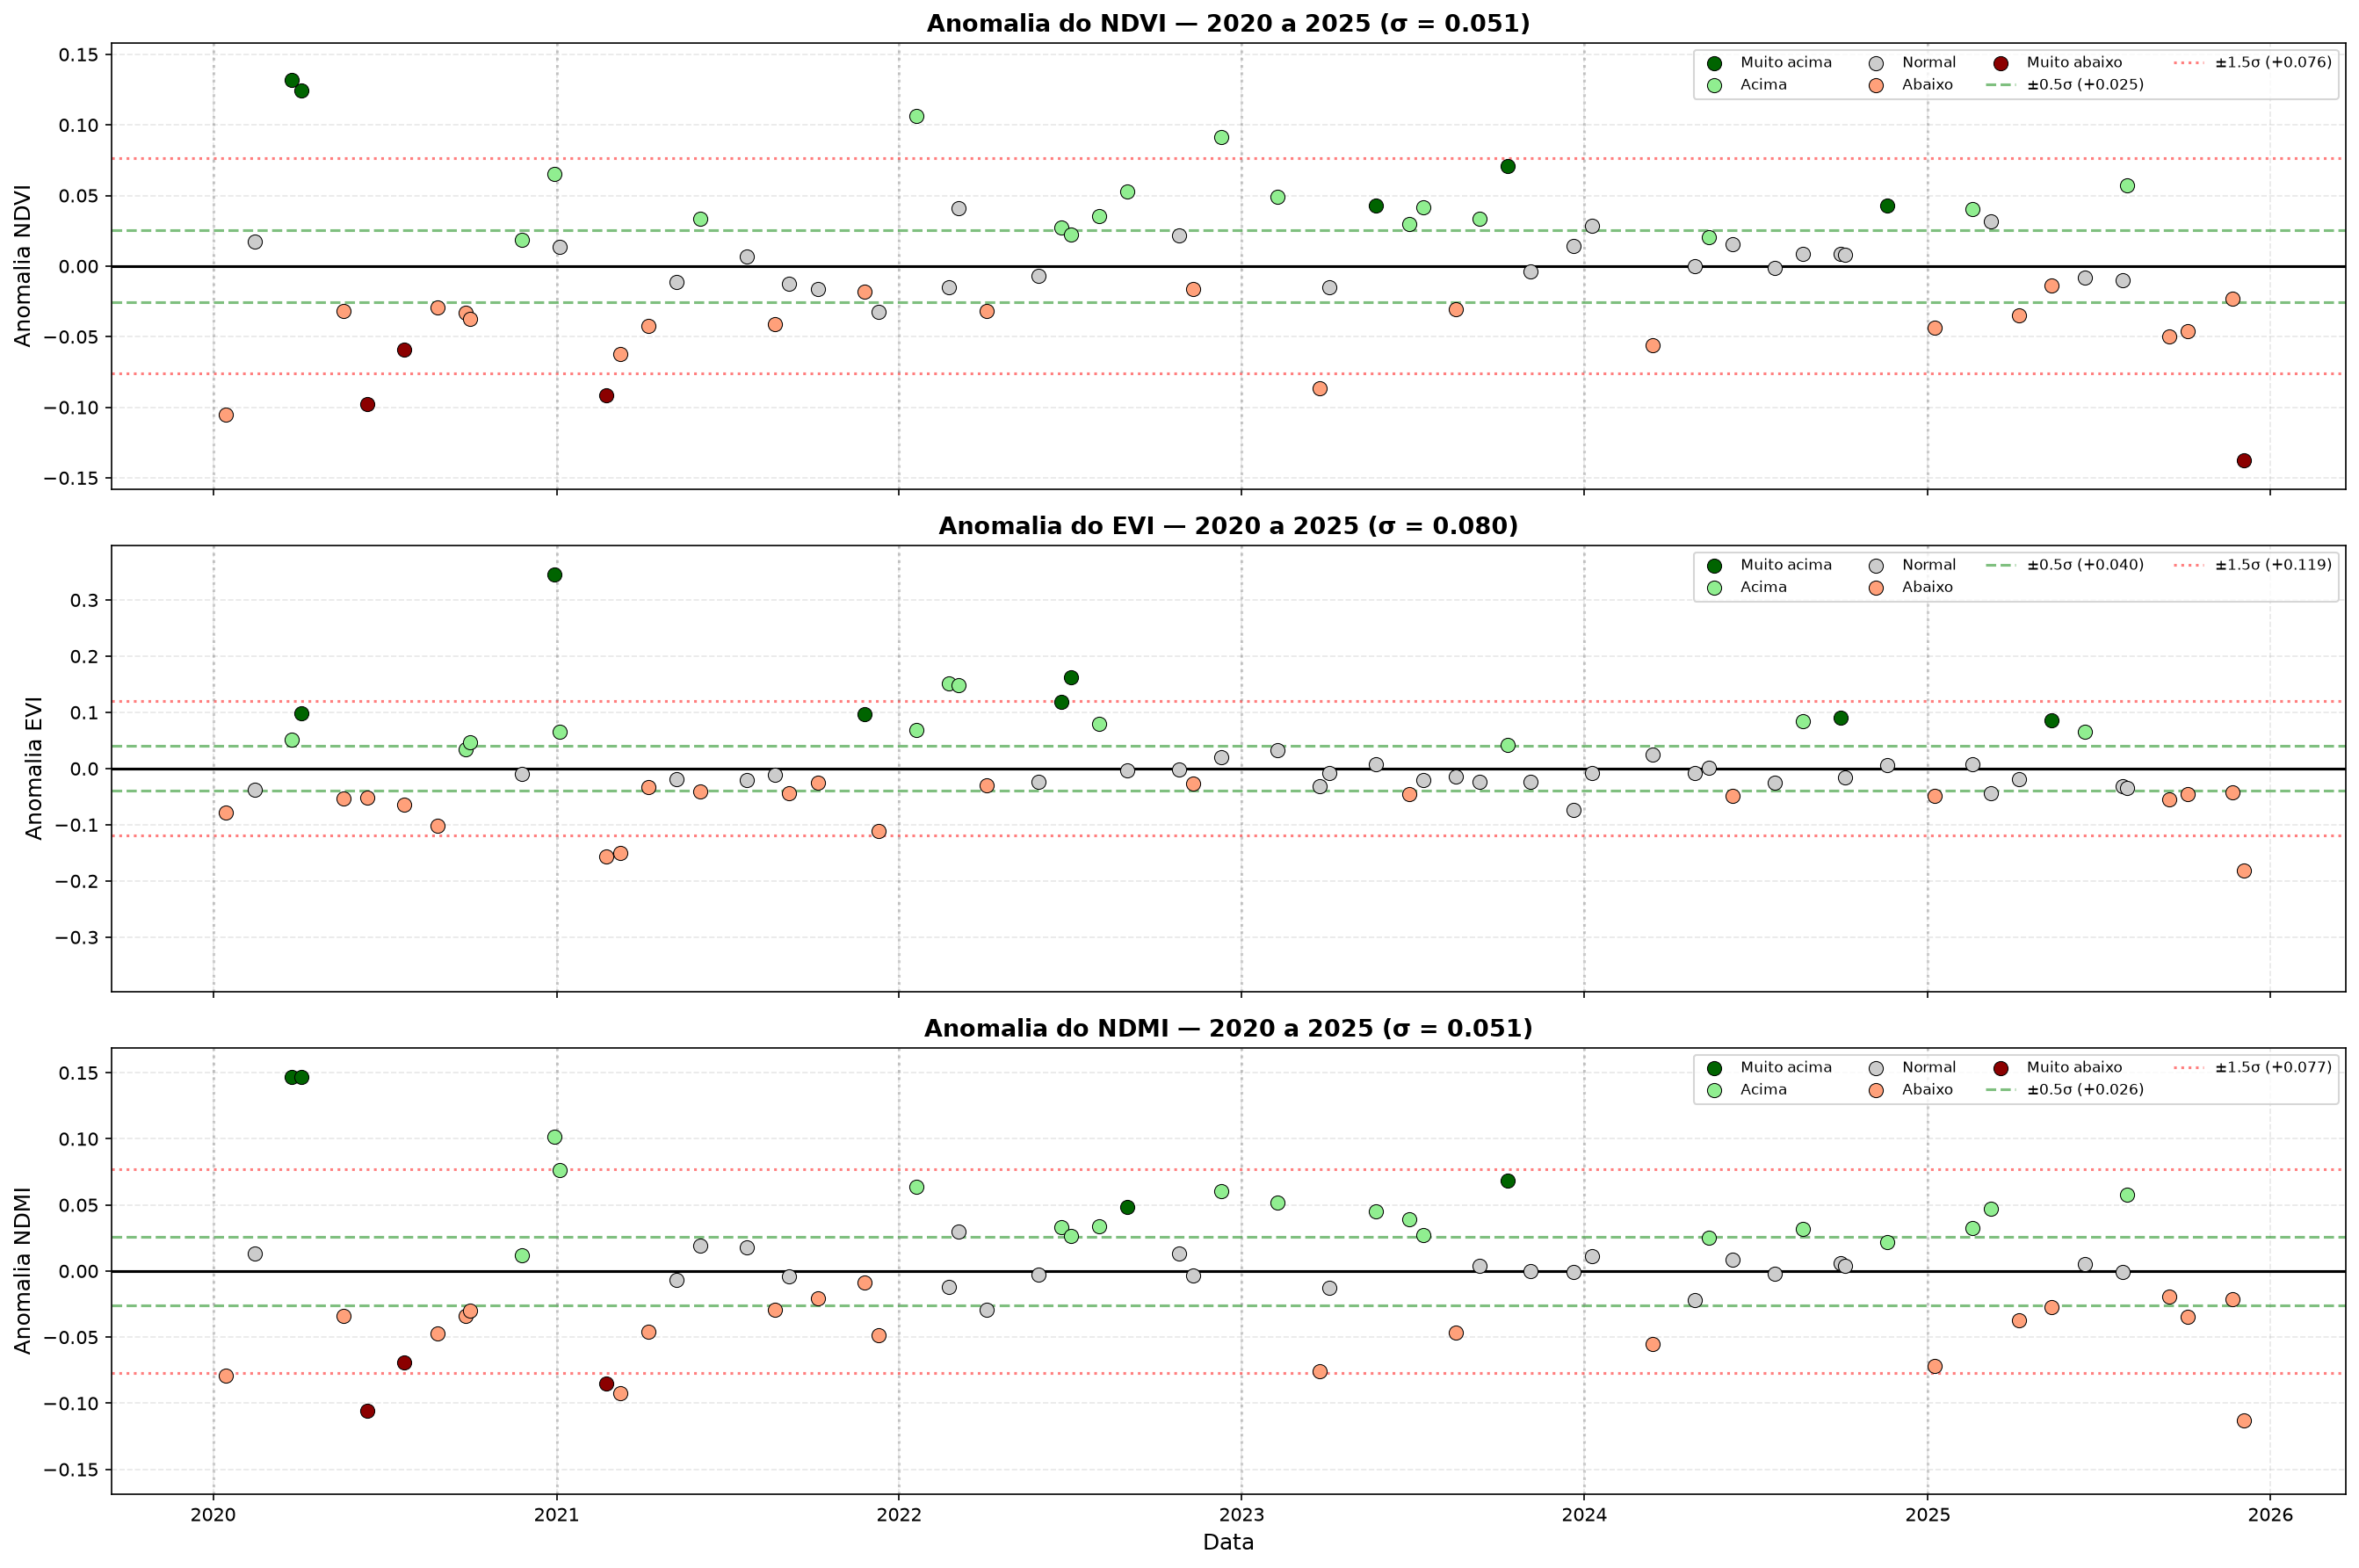

In [5]:
# ============================================================
# GRÁFICO — ANOMALIA POR DATA (2020-2025) — ESCALA CORRIGIDA
# ============================================================

cores_anom = {
    "Muito acima": "#006400",
    "Acima": "#90EE90",
    "Normal": "#CCCCCC",
    "Abaixo": "#FFA07A",
    "Muito abaixo": "#8B0000"
}

fig, axes = plt.subplots(3, 1, figsize=(18, 12), dpi=150, sharex=True)

for ax, indice in zip(axes, ["NDVI", "EVI", "NDMI"]):
    df = dfs_anomalias[indice]
    
    # Calcular o desvio padrão REAL das anomalias desse índice
    std_real = df["anomalia"].std()
    
    # Definir limites da escala com base nos dados reais
    lim = max(abs(df["anomalia"].min()), abs(df["anomalia"].max())) * 1.15
    
    # Separar por classe
    for classe, cor in cores_anom.items():
        mask = df["classificacao"] == classe
        if mask.sum() > 0:
            ax.scatter(df.loc[mask, "data"], df.loc[mask, "anomalia"],
                       c=cor, s=60, edgecolor="black", linewidth=0.5,
                       label=classe, zorder=3)
    
    # Linhas de referência em desvios padrão REAIS
    ax.axhline(0, color="black", linewidth=1.5)
    ax.axhline(+0.5 * std_real, color="green", linestyle="--", 
               alpha=0.5, label=f"±0.5σ ({0.5*std_real:+.3f})")
    ax.axhline(-0.5 * std_real, color="green", linestyle="--", alpha=0.5)
    ax.axhline(+1.5 * std_real, color="red", linestyle=":", 
               alpha=0.5, label=f"±1.5σ ({1.5*std_real:+.3f})")
    ax.axhline(-1.5 * std_real, color="red", linestyle=":", alpha=0.5)
    
    # Separadores por ano
    for ano in range(2020, 2026):
        ax.axvline(pd.Timestamp(f"{ano}-01-01"), color="gray",
                   linestyle=":", alpha=0.4)
    
    # Fixar limites da escala
    ax.set_ylim(-lim, lim)
    
    ax.set_ylabel(f"Anomalia {indice}", fontsize=12)
    ax.set_title(f"Anomalia do {indice} — 2020 a 2025 (σ = {std_real:.3f})",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper right", fontsize=8, ncol=4)

axes[-1].set_xlabel("Data", fontsize=12)
plt.tight_layout()

output = RESULTS_DIR / "anomalias_por_data.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

In [6]:
# ============================================================
# 8.2 — ANOMALIA ESPAÇO-TEMPORAL POR PIXEL
# ============================================================

resultados_espaciais = {}

for indice in ["NDVI", "EVI", "NDMI"]:

    cubo = cubos[indice]

    n_datas, altura, largura = cubo.shape

    print(f"\n{'='*70}")
    print(f"{indice}")
    print(f"{'='*70}")
    print(f"Cubo: {cubo.shape}")

    # --------------------------------------------------------
    # 1. Média histórica mensal de cada pixel
    # --------------------------------------------------------

    media_por_mes_pixel = np.full(
        (12, altura, largura),
        np.nan,
        dtype=float
    )

    for mes in range(1, 13):

        indices_mes = [
            i for i, data in enumerate(datas)
            if data.month == mes
        ]

        if indices_mes:

            media_por_mes_pixel[mes - 1] = np.nanmean(
                cubo[indices_mes],
                axis=0
            )

    # --------------------------------------------------------
    # 2. Anomalia de cada observação em relação à média
    #    histórica do respectivo mês
    # --------------------------------------------------------

    cubo_anomalia = np.full_like(
        cubo,
        np.nan,
        dtype=float
    )

    for i, data in enumerate(datas):

        mes = data.month

        cubo_anomalia[i] = (
            cubo[i] -
            media_por_mes_pixel[mes - 1]
        )

    # --------------------------------------------------------
    # 3. Estatísticas espaço-temporais
    # --------------------------------------------------------

    # Número de observações válidas por pixel
    valido = ~np.isnan(cubo_anomalia)

    n_validos = valido.sum(axis=0)

    # --------------------------------------------------------
    # Frequência de anomalias negativas
    # --------------------------------------------------------

    negativos = (
        (cubo_anomalia < -0.05) &
        valido
    )

    freq_negativa = np.where(
        n_validos > 0,
        negativos.sum(axis=0) / n_validos * 100,
        np.nan
    )

    # --------------------------------------------------------
    # Frequência de anomalias positivas
    # --------------------------------------------------------

    positivos = (
        (cubo_anomalia > 0.05) &
        valido
    )

    freq_positiva = np.where(
        n_validos > 0,
        positivos.sum(axis=0) / n_validos * 100,
        np.nan
    )

    # --------------------------------------------------------
    # Anomalia média por pixel
    # --------------------------------------------------------

    anomalia_media = np.nanmean(
        cubo_anomalia,
        axis=0
    )

    # --------------------------------------------------------
    # Desvio-padrão da anomalia por pixel
    # --------------------------------------------------------

    anomalia_std = np.nanstd(
        cubo_anomalia,
        axis=0
    )

    # --------------------------------------------------------
    # Armazenar resultados
    # --------------------------------------------------------

    resultados_espaciais[indice] = {
        "cubo_anomalia": cubo_anomalia,
        "media_por_mes_pixel": media_por_mes_pixel,
        "n_validos": n_validos,
        "freq_negativa": freq_negativa,
        "freq_positiva": freq_positiva,
        "anomalia_media": anomalia_media,
        "anomalia_std": anomalia_std
    }

    # --------------------------------------------------------
    # Resumo
    # --------------------------------------------------------

    pixels_validos = np.sum(n_validos > 0)

    print(f"Pixels válidos: {pixels_validos:,}")

    print(
        f"Observações válidas por pixel: "
        f"{np.nanmin(n_validos[n_validos > 0])}–"
        f"{np.nanmax(n_validos)}"
    )

    print(
        f"Frequência negativa média: "
        f"{np.nanmean(freq_negativa):.1f}%"
    )

    print(
        f"Frequência positiva média: "
        f"{np.nanmean(freq_positiva):.1f}%"
    )

    print(
        f"Anomalia média global: "
        f"{np.nanmean(anomalia_media):.4f}"
    )

    print(
        f"Desvio-padrão médio da anomalia: "
        f"{np.nanmean(anomalia_std):.4f}"
    )

print("\n✓ Análise espaço-temporal concluída.")


NDVI
Cubo: (69, 222, 140)
Pixels válidos: 31,080
Observações válidas por pixel: 69–69
Frequência negativa média: 18.6%
Frequência positiva média: 18.2%
Anomalia média global: 0.0000
Desvio-padrão médio da anomalia: 0.0785

EVI
Cubo: (69, 222, 140)
Pixels válidos: 31,080
Observações válidas por pixel: 51–69
Frequência negativa média: 17.2%
Frequência positiva média: 15.5%
Anomalia média global: -0.0000
Desvio-padrão médio da anomalia: 0.0694

NDMI
Cubo: (69, 112, 71)
Pixels válidos: 7,952
Observações válidas por pixel: 69–69
Frequência negativa média: 18.6%
Frequência positiva média: 17.4%
Anomalia média global: -0.0000
Desvio-padrão médio da anomalia: 0.0734

✓ Análise espaço-temporal concluída.


In [7]:
# ============================================================
# 8.3 — HOTSPOTS DE ANOMALIA PERSISTENTE
# ============================================================
# Critérios:
#   - Persistência temporal: >= 40%
#   - Anomalia negativa: < -0.05
#   - Anomalia positiva: > +0.05
#   - Conectividade espacial: 8 vizinhos
#   - Área mínima do cluster: 0.5 ha
# ============================================================

from scipy.ndimage import label
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
from pathlib import Path


# ============================================================
# PARÂMETROS
# ============================================================

LIMIAR_PERSISTENCIA = 40.0
LIMIAR_ANOMALIA = 0.05
AREA_MINIMA_HA = 0.5

estrutura = np.ones((3, 3))


# ============================================================
# FUNÇÃO — ÁREA DO PIXEL
# ============================================================

def obter_area_pixel_ha(indice):

    if indice == "NDMI":
        resolucao_m = 20.0
    else:
        resolucao_m = 10.0

    area_pixel_ha = (
        resolucao_m * resolucao_m
    ) / 10000

    print(
        f"   Resolução da grade: "
        f"{resolucao_m:.2f} × {resolucao_m:.2f} m"
    )

    print(
        f"   Área do pixel: "
        f"{area_pixel_ha:.4f} ha"
    )

    return area_pixel_ha


# ============================================================
# FUNÇÃO — FILTRAR CLUSTERS
# ============================================================

def filtrar_clusters(labeled, area_pixel_ha):

    clusters = []

    ids = np.unique(labeled)

    for cluster_id in ids:

        # 0 = fundo
        if cluster_id == 0:
            continue

        n_pixels = np.sum(
            labeled == cluster_id
        )

        area_ha = (
            n_pixels *
            area_pixel_ha
        )

        if area_ha >= AREA_MINIMA_HA:

            clusters.append({
                "id": int(cluster_id),
                "n_pixels": int(n_pixels),
                "area_ha": float(area_ha)
            })

    return clusters


# ============================================================
# PROCESSAMENTO DOS ÍNDICES
# ============================================================

resultados_hotspots = {}
tabela_hotspots = []

for indice in ["NDVI", "EVI", "NDMI"]:

    resultado = resultados_espaciais[indice]

    freq_negativa = resultado["freq_negativa"]
    freq_positiva = resultado["freq_positiva"]

    area_pixel_ha = obter_area_pixel_ha(indice)

    print(f"\n{'='*70}")
    print(f"{indice}")
    print(f"{'='*70}")

    print(
        f"Persistência mínima: "
        f"{LIMIAR_PERSISTENCIA}%"
    )

    print(
        f"Limiar de anomalia: "
        f"±{LIMIAR_ANOMALIA}"
    )

    print(
        f"Área mínima do cluster: "
        f"{AREA_MINIMA_HA} ha"
    )

    # --------------------------------------------------------
    # Máscaras
    # --------------------------------------------------------

    mask_neg = (
        (~np.isnan(freq_negativa)) &
        (freq_negativa >= LIMIAR_PERSISTENCIA)
    )

    mask_pos = (
        (~np.isnan(freq_positiva)) &
        (freq_positiva >= LIMIAR_PERSISTENCIA)
    )

    # --------------------------------------------------------
    # Conectividade espacial — 8 vizinhos
    # --------------------------------------------------------

    labeled_neg, _ = label(
        mask_neg,
        structure=estrutura
    )

    labeled_pos, _ = label(
        mask_pos,
        structure=estrutura
    )

    # --------------------------------------------------------
    # Filtragem por área
    # --------------------------------------------------------

    hotspots_neg = filtrar_clusters(
        labeled_neg,
        area_pixel_ha
    )

    hotspots_pos = filtrar_clusters(
        labeled_pos,
        area_pixel_ha
    )

    # --------------------------------------------------------
    # Armazenar resultados
    # --------------------------------------------------------

    resultados_hotspots[indice] = {
        "freq_negativa": freq_negativa,
        "freq_positiva": freq_positiva,
        "mask_negativa": mask_neg,
        "mask_positiva": mask_pos,
        "labeled_negativa": labeled_neg,
        "labeled_positiva": labeled_pos,
        "hotspots_negativos": hotspots_neg,
        "hotspots_positivos": hotspots_pos,
        "area_pixel_ha": area_pixel_ha
    }

    # --------------------------------------------------------
    # Tabela — negativos
    # --------------------------------------------------------

    for cluster in hotspots_neg:

        tabela_hotspots.append({
            "indice": indice,
            "tipo": "Negativo",
            "id_cluster": cluster["id"],
            "n_pixels": cluster["n_pixels"],
            "area_ha": cluster["area_ha"],
            "limiar_persistencia_pct":
                LIMIAR_PERSISTENCIA,
            "limiar_anomalia":
                -LIMIAR_ANOMALIA
        })

    # --------------------------------------------------------
    # Tabela — positivos
    # --------------------------------------------------------

    for cluster in hotspots_pos:

        tabela_hotspots.append({
            "indice": indice,
            "tipo": "Positivo",
            "id_cluster": cluster["id"],
            "n_pixels": cluster["n_pixels"],
            "area_ha": cluster["area_ha"],
            "limiar_persistencia_pct":
                LIMIAR_PERSISTENCIA,
            "limiar_anomalia":
                LIMIAR_ANOMALIA
        })

    # --------------------------------------------------------
    # Resumo
    # --------------------------------------------------------

    area_neg = sum(
        cluster["area_ha"]
        for cluster in hotspots_neg
    )

    area_pos = sum(
        cluster["area_ha"]
        for cluster in hotspots_pos
    )

    pixels_neg = sum(
        cluster["n_pixels"]
        for cluster in hotspots_neg
    )

    pixels_pos = sum(
        cluster["n_pixels"]
        for cluster in hotspots_pos
    )

    print(
        f"\nHotspots negativos: "
        f"{len(hotspots_neg)} clusters | "
        f"{pixels_neg:,} pixels | "
        f"{area_neg:.2f} ha"
    )

    print(
        f"Hotspots positivos: "
        f"{len(hotspots_pos)} clusters | "
        f"{pixels_pos:,} pixels | "
        f"{area_pos:.2f} ha"
    )


# ============================================================
# TABELA FINAL
# ============================================================

hotspots_df = pd.DataFrame(
    tabela_hotspots
)

if not hotspots_df.empty:

    hotspots_df = hotspots_df.sort_values(
        ["indice", "tipo", "area_ha"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

display(hotspots_df)


# ============================================================
# DIRETÓRIO RESULTS
# ============================================================

results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# EXPORTAR TABELA
# ============================================================

arquivo_hotspots = (
    results_dir /
    "hotspots_anomalia.csv"
)

hotspots_df.to_csv(
    arquivo_hotspots,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✓ Tabela de hotspots salva em:"
)

print(
    arquivo_hotspots.resolve()
)




   Resolução da grade: 10.00 × 10.00 m
   Área do pixel: 0.0100 ha

NDVI
Persistência mínima: 40.0%
Limiar de anomalia: ±0.05
Área mínima do cluster: 0.5 ha

Hotspots negativos: 10 clusters | 4,697 pixels | 46.97 ha
Hotspots positivos: 7 clusters | 1,508 pixels | 15.08 ha
   Resolução da grade: 10.00 × 10.00 m
   Área do pixel: 0.0100 ha

EVI
Persistência mínima: 40.0%
Limiar de anomalia: ±0.05
Área mínima do cluster: 0.5 ha

Hotspots negativos: 6 clusters | 1,192 pixels | 11.92 ha
Hotspots positivos: 0 clusters | 0 pixels | 0.00 ha
   Resolução da grade: 20.00 × 20.00 m
   Área do pixel: 0.0400 ha

NDMI
Persistência mínima: 40.0%
Limiar de anomalia: ±0.05
Área mínima do cluster: 0.5 ha

Hotspots negativos: 11 clusters | 1,007 pixels | 40.28 ha
Hotspots positivos: 1 clusters | 31 pixels | 1.24 ha


,indice,tipo,id_cluster,n_pixels,area_ha,limiar_persistencia_pct,limiar_anomalia
0,EVI,Negativo,65,516,5.160,40.000,-0.050
1,EVI,Negativo,163,357,3.570,40.000,-0.050
2,EVI,Negativo,165,111,1.110,40.000,-0.050
3,EVI,Negativo,17,88,0.880,40.000,-0.050
4,EVI,Negativo,106,65,0.650,40.000,-0.050
5,EVI,Negativo,133,55,0.550,40.000,-0.050
6,NDMI,Negativo,5,359,14.360,40.000,-0.050
7,NDMI,Negativo,12,216,8.640,40.000,-0.050
8,NDMI,Negativo,37,113,4.520,40.000,-0.050
9,NDMI,Negativo,41,99,3.960,40.000,-0.050



✓ Tabela de hotspots salva em:
C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\hotspots_anomalia.csv


NDVI: 19281 pixels válidos
EVI: 19281 pixels válidos
NDMI: 4907 pixels válidos


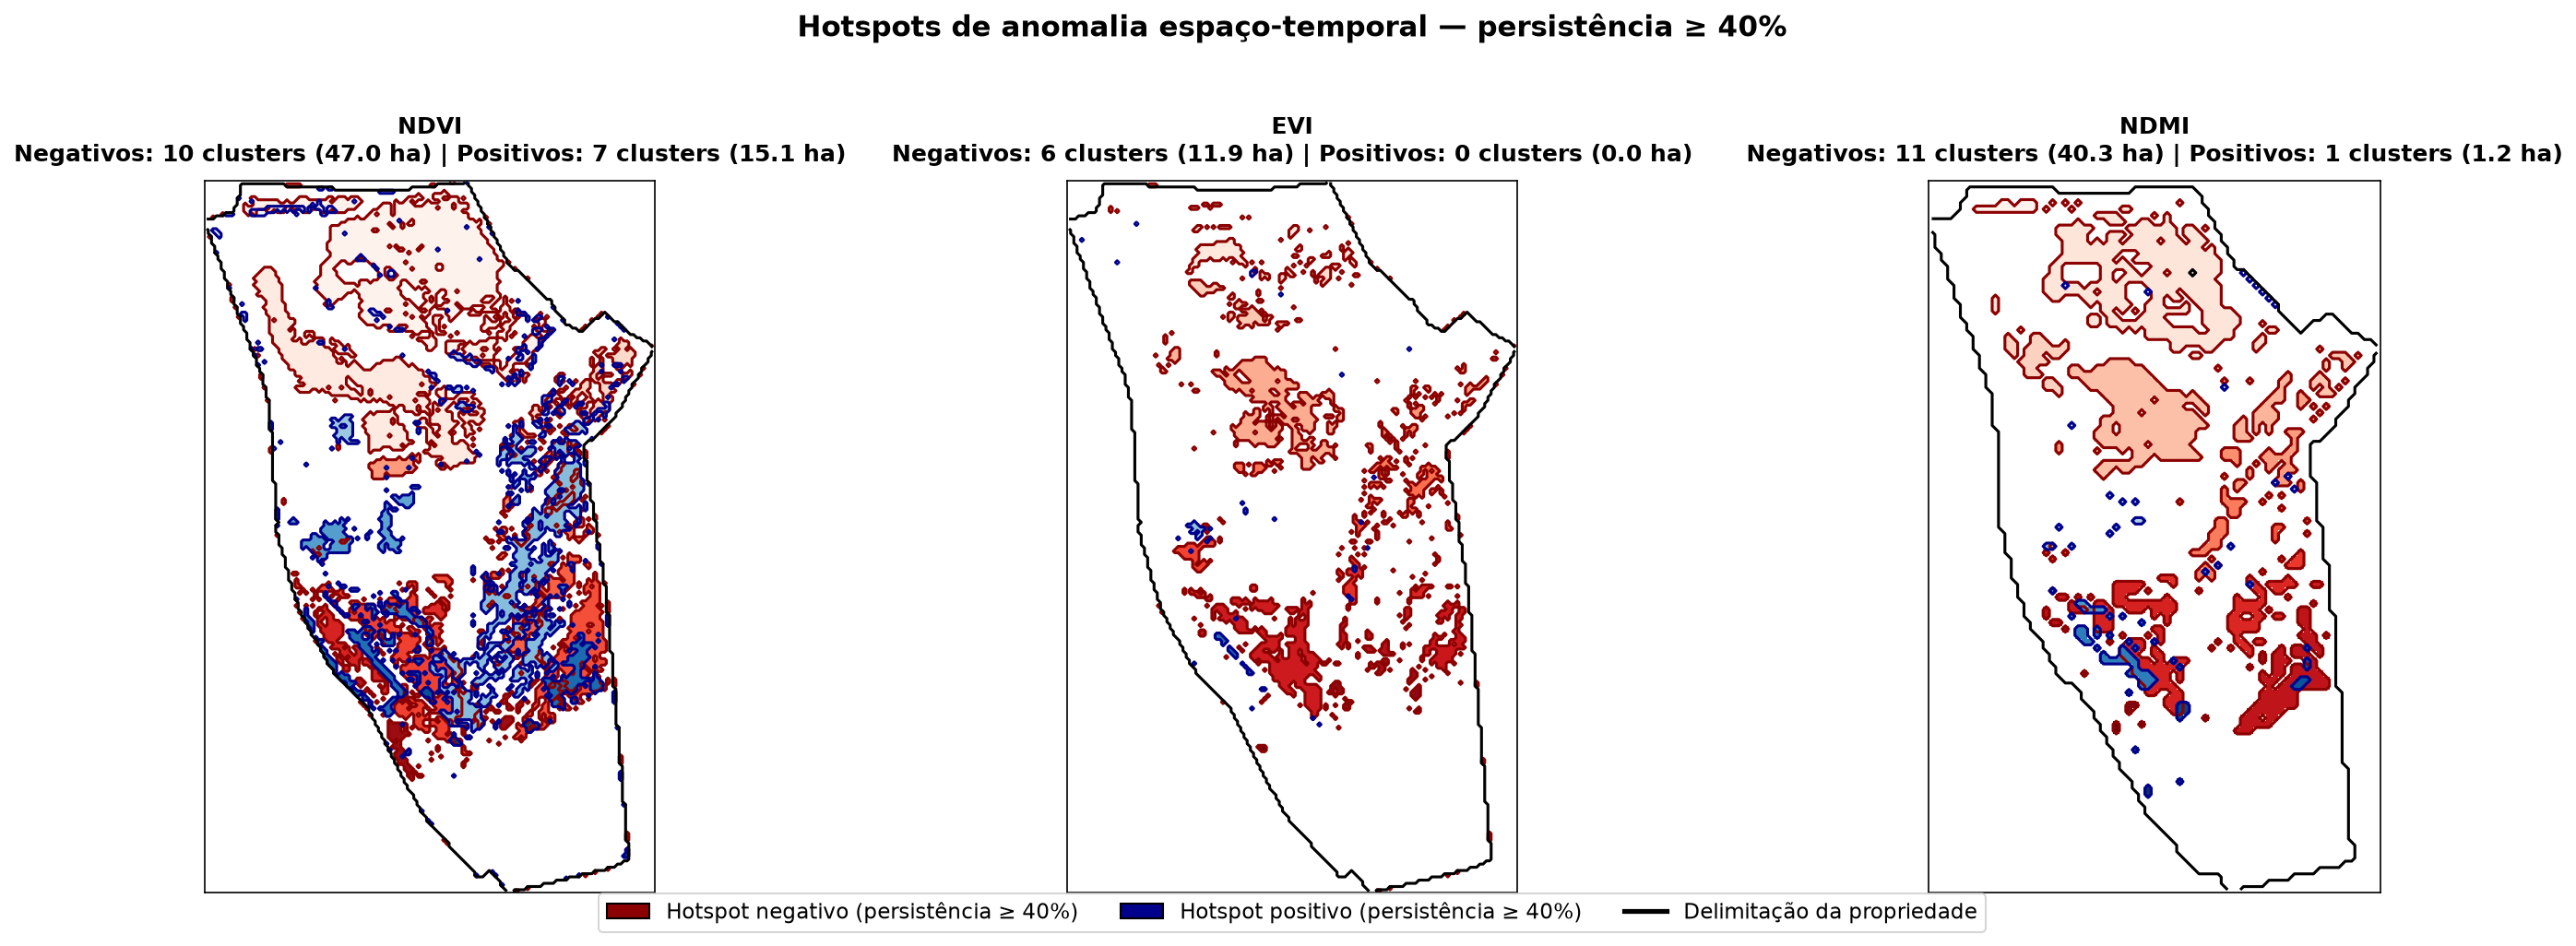

✓ Mapa salvo em: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\08_mapa_hotspots_40pct_com_delimitacao.png


In [8]:
# ============================================================
# MAPA DOS HOTSPOTS — COM DELIMITAÇÃO DA PROPRIEDADE
# ============================================================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from pathlib import Path

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"

# ------------------------------------------------------------
# Máscara da propriedade — usando nodata (0.0)
# ------------------------------------------------------------
ndvi_ref = rioxarray.open_rasterio(IND_DIR / "ndvi" / "ndvi_20200115.tif").squeeze()
evi_ref  = rioxarray.open_rasterio(IND_DIR / "evi"  / "evi_20200115.tif").squeeze()
ndmi_ref = rioxarray.open_rasterio(IND_DIR / "ndmi" / "ndmi_20200115.tif").squeeze()

mask_prop = {
    "NDVI": ndvi_ref.values != ndvi_ref.rio.nodata,
    "EVI":  evi_ref.values  != evi_ref.rio.nodata,
    "NDMI": ndmi_ref.values != ndmi_ref.rio.nodata,
}

# ------------------------------------------------------------
# Sanity check — deve imprimir 31.080 / 31.080 / 4.907
# ------------------------------------------------------------
for k, m in mask_prop.items():
    print(f"{k}: {m.sum()} pixels válidos")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=150)

for ax, indice in zip(axes, ["NDVI", "EVI", "NDMI"]):
    resultado = resultados_hotspots[indice]
    mask_neg = resultado["mask_negativa"]
    mask_pos = resultado["mask_positiva"]
    labeled_neg = resultado["labeled_negativa"]
    labeled_pos = resultado["labeled_positiva"]

    ax.set_facecolor("white")

    mapa_neg = np.ma.masked_where(~mask_neg, labeled_neg)
    ax.imshow(mapa_neg, cmap="Reds", vmin=0, vmax=labeled_neg.max(),
              interpolation="nearest", alpha=1.0)

    mapa_pos = np.ma.masked_where(~mask_pos, labeled_pos)
    ax.imshow(mapa_pos, cmap="Blues", vmin=0, vmax=labeled_pos.max(),
              interpolation="nearest", alpha=1.0)

    ax.contour(mask_neg, colors="darkred", linewidths=1.5, levels=[0.5])
    ax.contour(mask_pos, colors="darkblue", linewidths=1.5, levels=[0.5])

    # ---- DELIMITAÇÃO DA PROPRIEDADE ----
    ax.contour(mask_prop[indice], colors="black",
               linewidths=1.5, levels=[0.5], zorder=20)

    n_neg = len(resultado["hotspots_negativos"])
    n_pos = len(resultado["hotspots_positivos"])
    area_neg = sum(c["area_ha"] for c in resultado["hotspots_negativos"])
    area_pos = sum(c["area_ha"] for c in resultado["hotspots_positivos"])

    ax.set_title(f"{indice}\n"
                 f"Negativos: {n_neg} clusters ({area_neg:.1f} ha) | "
                 f"Positivos: {n_pos} clusters ({area_pos:.1f} ha)",
                 fontsize=12, fontweight="bold", pad=10)

    ax.margins(0.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")

legenda = [
    Patch(facecolor="darkred", edgecolor="black",
          label="Hotspot negativo (persistência ≥ 40%)"),
    Patch(facecolor="darkblue", edgecolor="black",
          label="Hotspot positivo (persistência ≥ 40%)"),
    Line2D([0], [0], color="black", linewidth=2.5,
           label="Delimitação da propriedade"),
]

fig.legend(handles=legenda, loc="lower center", ncol=3, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, 0.02))

fig.suptitle("Hotspots de anomalia espaço-temporal — persistência ≥ 40%",
             fontsize=15, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

output = RESULTS_DIR / "08_mapa_hotspots_40pct_com_delimitacao.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Mapa salvo em: {output.resolve()}")